In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

# Ruta a la carpeta pr1 (ajusta si es necesario)
path_pr1 = "./pr1/" 

# Listamos los archivos para verificar
files = sorted(glob.glob(os.path.join(path_pr1, "*.nc")))
print(f"Se encontraron {len(files)} archivos en {path_pr1}")
for f in files:
    print(os.path.basename(f))

Se encontraron 8 archivos en ./pr1/
pr_CHP12_CNRM-ESM2-1_historical_r1i1p1f2_CNRM-ALADIN64_v1_day_19500101-19781231_chile.nc
pr_CHP12_CNRM-ESM2-1_historical_r1i1p1f2_CNRM-ALADIN64_v1_day_19790101-20141231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp370_r1i1p1f2_CNRM-ALADIN64_v1_day_20150101-20391231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp370_r1i1p1f2_CNRM-ALADIN64_v1_day_20400101-20641231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp370_r1i1p1f2_CNRM-ALADIN64_v1_day_20650101-21001231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp585_r1i1p1f2_CNRM-ALADIN64_v1_day_20150101-20391231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp585_r1i1p1f2_CNRM-ALADIN64_v1_day_20400101-20641231_chile.nc
pr_CHP12_CNRM-ESM2-1_ssp585_r1i1p1f2_CNRM-ALADIN64_v1_day_20650101-21001231_chile.nc


---

## 2. Unión de la Serie Histórica y Proyecciones
A diferencia de CR2MET, aquí tienes que decidir qué "futuro" quieres analizar (SSP370 o SSP585). Vamos a crear una función que cargue la serie completa (Histórica + Escenario).

In [2]:
def load_katerina_scenario(scenario_name="ssp585"):
    """
    Carga los archivos históricos y los concatena con el escenario elegido.
    """
    # Archivos históricos (1950-2014)
    hist_files = [f for f in files if "historical" in f]
    
    # Archivos del escenario (2015-2100)
    scen_files = [f for f in files if scenario_name in f]
    
    # Unimos las listas y cargamos con xarray
    all_files = hist_files + scen_files
    
    # Abrimos todos los archivos concatenándolos en la dimensión tiempo
    ds_kat = xr.open_mfdataset(all_files, concat_dim="time", combine="nested")
    
    # Aseguramos que las unidades de pr sean consistentes (suelen venir en kg/m2/s o mm/day)
    # Si es necesario, convertimos aquí.
    return ds_kat

# Cargamos el escenario SSP5-8.5 (el más extremo)
ds_kat = load_katerina_scenario("ssp585")
print("\nDataset cargado correctamente:")
print(ds_kat)


Dataset cargado correctamente:
<xarray.Dataset> Size: 65GB
Dimensions:      (time: 55152, y: 255, x: 68, nvertex: 4, axis_nbounds: 2)
Coordinates:
  * time         (time) datetime64[ns] 441kB 1950-01-01T12:00:00 ... 2100-12-...
    lat          (y, x) float64 139kB dask.array<chunksize=(255, 68), meta=np.ndarray>
    lon          (y, x) float64 139kB dask.array<chunksize=(255, 68), meta=np.ndarray>
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_lat   (time, y, x, nvertex) float64 31GB dask.array<chunksize=(10592, 255, 68, 4), meta=np.ndarray>
    bounds_lon   (time, y, x, nvertex) float64 31GB dask.array<chunksize=(10592, 255, 68, 4), meta=np.ndarray>
    pr           (time, y, x) float32 4GB dask.array<chunksize=(1, 255, 68), meta=np.ndarray>
    time_bounds  (time, axis_nbounds) datetime64[ns] 882kB dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes: (12/30)
    description:                                      Created by xios
    Conven

C:\Users\elxpa\AppData\Local\Temp\ipykernel_24052\3689628994.py:15: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_kat = xr.open_mfdataset(all_files, concat_dim="time", combine="nested")


In [3]:
import numpy as np
import pandas as pd

# 1. Coordenadas de Santiago
lat_target, lon_target = -33.45, -70.66

# 2. Encontrar índices (y, x) más cercanos
# Calculamos la distancia usando las coordenadas 2D 'lat' y 'lon'
dist = np.sqrt((ds_kat.lat - lat_target)**2 + (ds_kat.lon - lon_target)**2)
indices = dist.argmin(dim=["y", "x"])

# 3. Extraer la serie y convertir a mm/día
# Seleccionamos por índice (isel) y cargamos en memoria (.compute)
stgo_series = ds_kat["pr"].isel(y=indices["y"], x=indices["x"]).compute()

# Crear DataFrame
df_kat = stgo_series.to_dataframe()[["pr"]]

# 4. Conversión de unidades (de kg/m2/s a mm/día)
# Multiplicamos por 86400 (segundos en un día)
df_kat["pr"] = df_kat["pr"] * 86400

# 5. Limpieza de "llovizna" (Drizzle effect)
# Aplicamos el umbral de 1mm para definir un día seco real
df_kat["pr"] = np.where(df_kat["pr"] < 1.0, 0, df_kat["pr"])

print("Serie de Santiago (Katerina) lista:")
print(df_kat.describe())

Serie de Santiago (Katerina) lista:
                 pr
count  55152.000000
mean       3.756280
std       10.799019
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max      197.353561


---

## 2. Detección de Dry Spells y Tendencias (5-year Rolling)
Ahora aplicamos la misma lógica que usamos en CR2MET para ver la evolución histórica y futura.

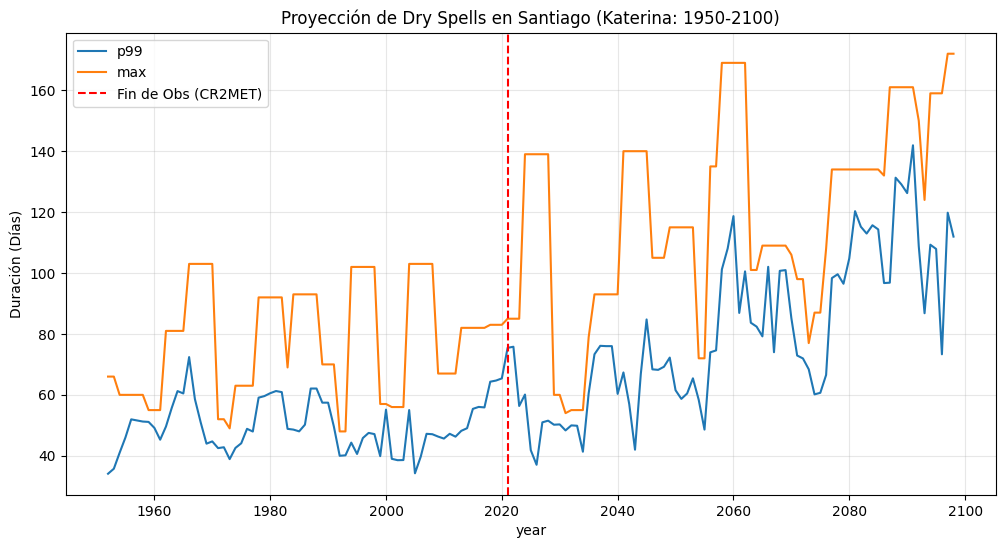

In [4]:
# Función para detectar rachas (la que ya teníamos)
def get_dry_spells(series):
    is_dry = series < 1.0
    tokens = is_dry.astype(int).diff().fillna(0)
    starts = np.where(tokens == 1)[0]
    ends = np.where(tokens == -1)[0]
    if is_dry.iloc[0]: starts = np.insert(starts, 0, 0)
    if is_dry.iloc[-1]: ends = np.append(ends, len(series)-1)
    durations = ends - starts
    return pd.DataFrame({"start": series.index[starts], "duration": durations})

# Calculamos las rachas
df_spells_kat = get_dry_spells(df_kat["pr"])
df_spells_kat["year"] = df_spells_kat["start"].dt.year

# Cálculo de métricas en ventanas móviles de 5 años (1950-2100)
results = []
years = np.arange(1950, 2097)

for y in years:
    mask = (df_spells_kat["year"] >= y) & (df_spells_kat["year"] <= y+4)
    data = df_spells_kat.loc[mask, "duration"]
    if not data.empty:
        results.append({
            "year": y + 2,
            "p99": np.percentile(data, 99),
            "max": data.max(),
            "mean": data.mean()
        })

df_trends_kat = pd.DataFrame(results).set_index("year")

# Graficar la tendencia de largo plazo
df_trends_kat[["p99", "max"]].plot(figsize=(12,6), title="Proyección de Dry Spells en Santiago (Katerina: 1950-2100)")
plt.axvline(x=2021, color='r', linestyle='--', label='Fin de Obs (CR2MET)')
plt.ylabel("Duración (Días)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<>:90: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:90: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
C:\Users\elxpa\AppData\Local\Temp\ipykernel_24052\1865166202.py:90: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  tL_str = f"{tL:.1f}d" if tL != np.inf else "$\infty$"


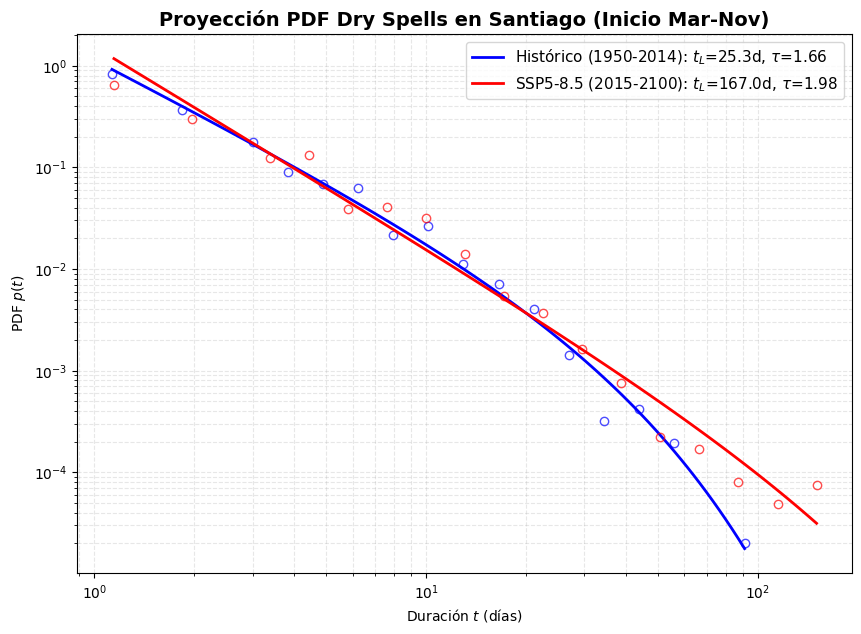

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Función para extraer y filtrar Dry Spells desde el DataFrame de Pandas
def extract_seasonal_spells_pd(df_precip, filter_type='start'):
    """
    df_precip: DataFrame con índice de fechas y columna 'pr' (mm/día)
    """
    is_dry = df_precip['pr'] < 1.0
    
    # Identificar inicios y términos
    x = np.r_[False, is_dry.values, False]
    dx = np.diff(x.astype(int))
    starts = np.where(dx == 1)[0]
    ends = np.where(dx == -1)[0]
    
    durations = ends - starts
    valid = durations > 0
    starts = starts[valid]
    ends = ends[valid]
    durations = durations[valid]
    
    if len(durations) == 0:
        return np.array([])
        
    # Extraer meses usando el índice de fechas de Pandas
    fechas = df_precip.index
    start_months = fechas[starts].month
    end_months = fechas[ends - 1].month # ends-1 es el último día seco de la racha
    
    # Aplicar el filtro estacional (Marzo=3 a Noviembre=11)
    if filter_type == 'start':
        mask = (start_months >= 3) & (start_months <= 11)
    elif filter_type == 'end':
        mask = (end_months >= 3) & (end_months <= 11)
    else:
        mask = np.ones_like(durations, dtype=bool) # Sin filtro
        
    return durations[mask]

# 2. Separar la data en Histórica y Futura (SSP5-8.5)
df_hist = df_kat.loc['1950':'2014']
df_fut = df_kat.loc['2015':'2100']

# Extraer duraciones con FORMA 1 (Inicio en Mar-Nov)
# (Para revisar la Forma 2, simplemente cambia 'start' por 'end')
durs_hist = extract_seasonal_spells_pd(df_hist, filter_type='start')
durs_fut  = extract_seasonal_spells_pd(df_fut, filter_type='start')

# 3. Preparar el gráfico de PDF y Ajuste Log-Lineal
periodos = [
    {"data": durs_hist, "label": "Histórico (1950-2014)", "color": "blue"},
    {"data": durs_fut,  "label": "SSP5-8.5 (2015-2100)", "color": "red"}
]

plt.figure(figsize=(10, 7))

for p in periodos:
    data = p["data"]
    if len(data) < 3:
        continue # Prevenir errores si no hay datos suficientes
        
    # Binning logarítmico
    bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 20)
    counts, bin_edges = np.histogram(data, bins=bins, density=True)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    
    valid_bins = counts > 0
    x_val = bin_centers[valid_bins]
    y_val = counts[valid_bins]
    
    # Fit por Mínimos Cuadrados (Log-Lineal del paper)
    if len(x_val) >= 3:
        Y = np.log(y_val)
        X_matrix = np.column_stack((np.ones(len(x_val)), np.log(x_val), x_val))
        c, _, _, _ = np.linalg.lstsq(X_matrix, Y, rcond=None)
        c1, c2, c3 = c
        
        tau = -c2
        tL = -1.0 / c3 if c3 < 0 else np.inf 
        A_fit = np.exp(c1)
        
        # Crear la curva teórica para el gráfico
        t_range = np.logspace(np.log10(min(x_val)), np.log10(max(x_val)), 100)
        fit_curve = A_fit * (t_range**(-tau)) * np.exp(-t_range/tL)
        
        # Graficar puntos (scatter) y línea de ajuste
        plt.loglog(x_val, y_val, 'o', color=p["color"], mfc='none', alpha=0.7)
        
        tL_str = f"{tL:.1f}d" if tL != np.inf else "$\infty$"
        plt.plot(t_range, fit_curve, color=p["color"], lw=2,
                 label=f"{p['label']}: $t_L$={tL_str}, $\\tau$={tau:.2f}")

# Estética final del gráfico
plt.title("Proyección PDF Dry Spells en Santiago (Inicio Mar-Nov)", fontsize=14, fontweight='bold')
plt.xlabel("Duración $t$ (días)")
plt.ylabel("PDF $p(t)$")
plt.legend(fontsize=11)
plt.grid(True, which="both", ls="--", alpha=0.3)
plt.show()

In [8]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy import stats

# 1. PREPARACIÓN DE DATOS (Conversión a mm/día y Carga en memoria)
print("Cargando y convirtiendo datos Katerina a mm/día...")
# Multiplicamos por 86400 para pasar de kg/m2/s a mm/día
p_hist = (ds_kat["pr"].sel(time=slice("1950-01-01", "2014-12-31")) * 86400).compute()
p_fut  = (ds_kat["pr"].sel(time=slice("2015-01-01", "2100-12-31")) * 86400).compute()

# Extraer meses y renombrar la dimensión temporal del futuro para evitar AlignmentError
m_hist = p_hist['time'].dt.month
p_fut_renamed = p_fut.rename({'time': 'time2'})
m_fut  = p_fut_renamed['time2'].dt.month

# 2. FUNCIÓN DE CÁLCULO
def calc_katerina_trends_and_sig(pr1, mo1, pr2, mo2, filter_type='start'):
    def get_valid_durations(pr, mo):
        if np.isnan(pr).all(): return np.array([])
        dry = pr < 1.0
        if not np.any(dry): return np.array([])
        
        x = np.r_[False, dry, False]
        dx = np.diff(x.astype(int))
        starts = np.where(dx == 1)[0]
        ends = np.where(dx == -1)[0]
        durs = ends - starts
        
        valid = durs > 0
        starts = starts[valid]
        ends = ends[valid]
        durs = durs[valid]
        
        if len(durs) == 0: return np.array([])
        
        sm = mo[starts]
        em = mo[ends - 1]
        
        if filter_type == 'start': mask = (sm >= 3) & (sm <= 11)
        elif filter_type == 'end': mask = (em >= 3) & (em <= 11)
        else: mask = np.ones_like(durs, dtype=bool)
            
        return durs[mask]

    durs1 = get_valid_durations(pr1, mo1)
    durs2 = get_valid_durations(pr2, mo2)
    
    if len(durs1) < 3 or len(durs2) < 3:
        return np.array([np.nan]*6)
        
    def get_tL(durs):
        try:
            bins = np.logspace(np.log10(min(durs)), np.log10(max(durs)), 15)
            counts, bin_edges = np.histogram(durs, bins=bins, density=True)
            bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
            valid = counts > 0
            if np.sum(valid) >= 3:
                Y = np.log(counts[valid])
                X_mat = np.column_stack((np.ones(np.sum(valid)), np.log(bin_centers[valid]), bin_centers[valid]))
                c, _, _, _ = np.linalg.lstsq(X_mat, Y, rcond=None)
                return -1.0 / c[2] if c[2] < 0 else np.nan
        except: pass
        return np.nan

    mean1, tL1, t99_1 = np.mean(durs1), get_tL(durs1), np.percentile(durs1, 99)
    mean2, tL2, t99_2 = np.mean(durs2), get_tL(durs2), np.percentile(durs2, 99)
    
    # LA DIFERENCIA TEMPORAL ES ~75 AÑOS (7.5 DÉCADAS)
    decades = 7.5
    t_mean = (mean2 - mean1) / decades
    t_tL   = (tL2 - tL1) / decades
    t_t99  = (t99_2 - t99_1) / decades
    
    _, pval_mean = stats.ttest_ind(durs1, durs2, equal_var=False)
    _, pval_dist = stats.ks_2samp(durs1, durs2)
    
    return np.array([t_mean, t_tL, t_t99, pval_mean, pval_dist, pval_dist])

# Configuración visual compartida
metrics = ['trend_mean', 'trend_tL', 'trend_t99']
pvals   = ['pval_mean', 'pval_tL', 'pval_t99']
titles  = ['Tendencia Promedio', 'Tendencia Cutoff ($t_L$)', 'Tendencia P99 ($t_{99}$)']
vmins, vmaxs = [-2, -15, -10], [2, 15, 10]

Cargando y convirtiendo datos Katerina a mm/día...


Calculando Proyección FORMA 1 (Katerina SSP5-8.5)...


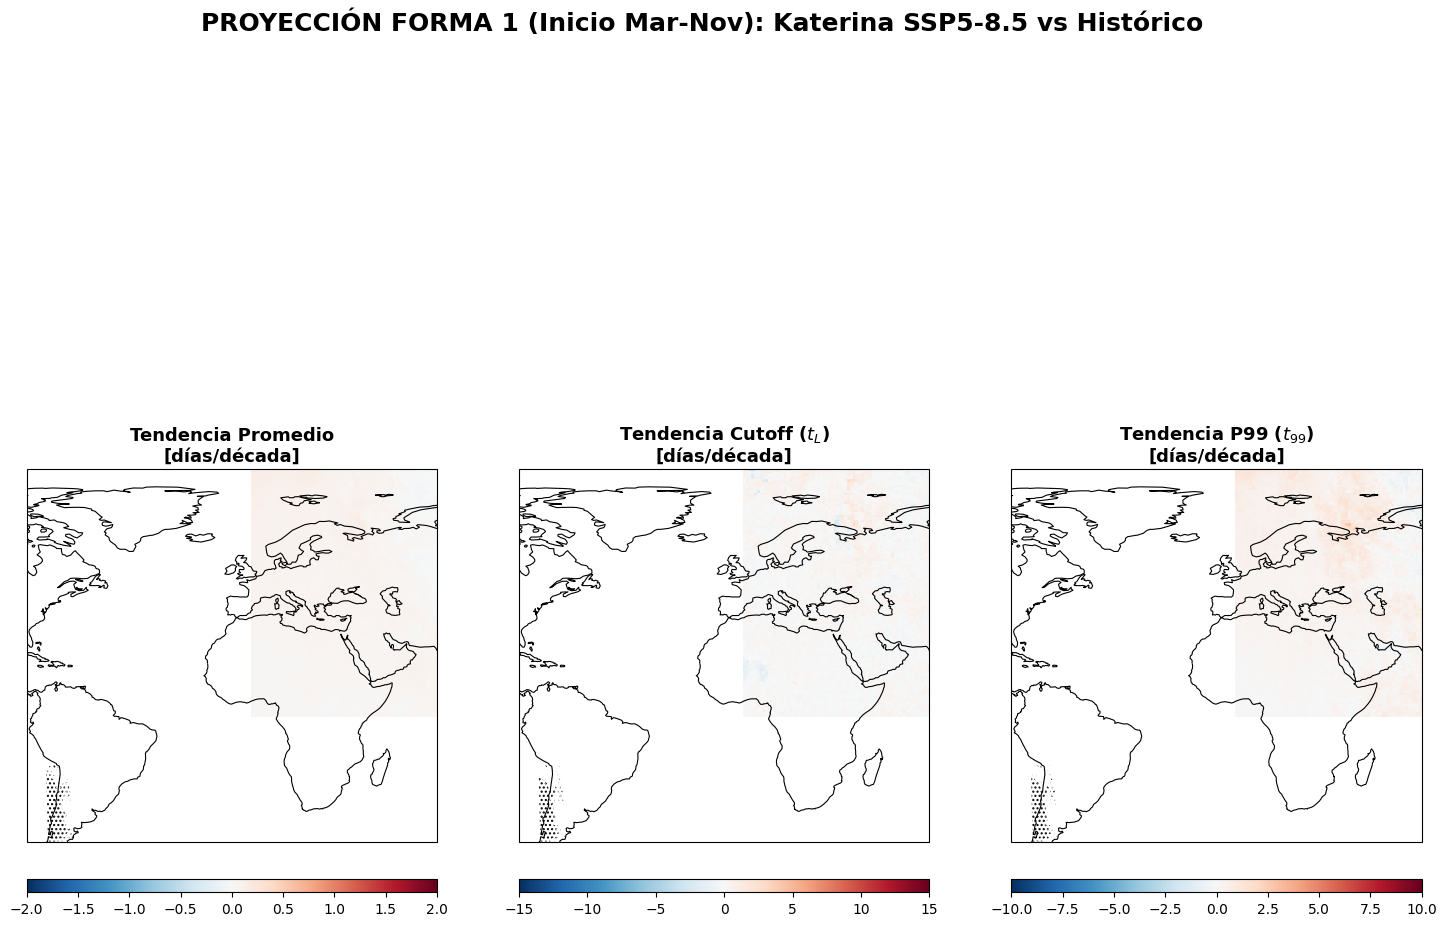

In [12]:
# Wrapper Forma 1
def wrapper_katerina_start(pr1, mo1, pr2, mo2):
    return calc_katerina_trends_and_sig(pr1, mo1, pr2, mo2, filter_type='start')

print("Calculando Proyección FORMA 1 (Katerina SSP5-8.5)...")
res_kat_start = xr.apply_ufunc(
    wrapper_katerina_start, p_hist, m_hist, p_fut_renamed, m_fut,
    input_core_dims=[['time'], ['time'], ['time2'], ['time2']],
    output_core_dims=[['output_var']],
    vectorize=True, dask="forbidden"
).assign_coords(output_var=['trend_mean', 'trend_tL', 'trend_t99', 'pval_mean', 'pval_tL', 'pval_t99'])

# Gráfico Forma 1
fig, axes = plt.subplots(1, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})
for i, ax in enumerate(axes):
    trend_data = res_kat_start.sel(output_var=metrics[i])
    pval_data  = res_kat_start.sel(output_var=pvals[i])
    
    im = trend_data.plot(ax=ax, cmap='RdBu_r', vmin=vmins[i], vmax=vmaxs[i], 
                         add_colorbar=False, transform=ccrs.PlateCarree())
    
    # Puntillado de significancia p < 0.05
    sig_mask = pval_data < 0.05
    if sig_mask.any():
        ax.contourf(trend_data.lon, trend_data.lat, sig_mask, 
                    levels=[0.5, 1.5], colors='none', hatches=['....'], 
                    transform=ccrs.PlateCarree())
    
    ax.coastlines(linewidth=0.8)
    ax.set_title(f"{titles[i]}\n[días/década]", fontweight='bold', fontsize=13)
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, aspect=30)

plt.suptitle("PROYECCIÓN FORMA 1 (Inicio Mar-Nov): Katerina SSP5-8.5 vs Histórico", fontsize=18, y=0.95, fontweight='bold')
plt.show()

Calculando Proyección FORMA 2 (Katerina SSP5-8.5)...


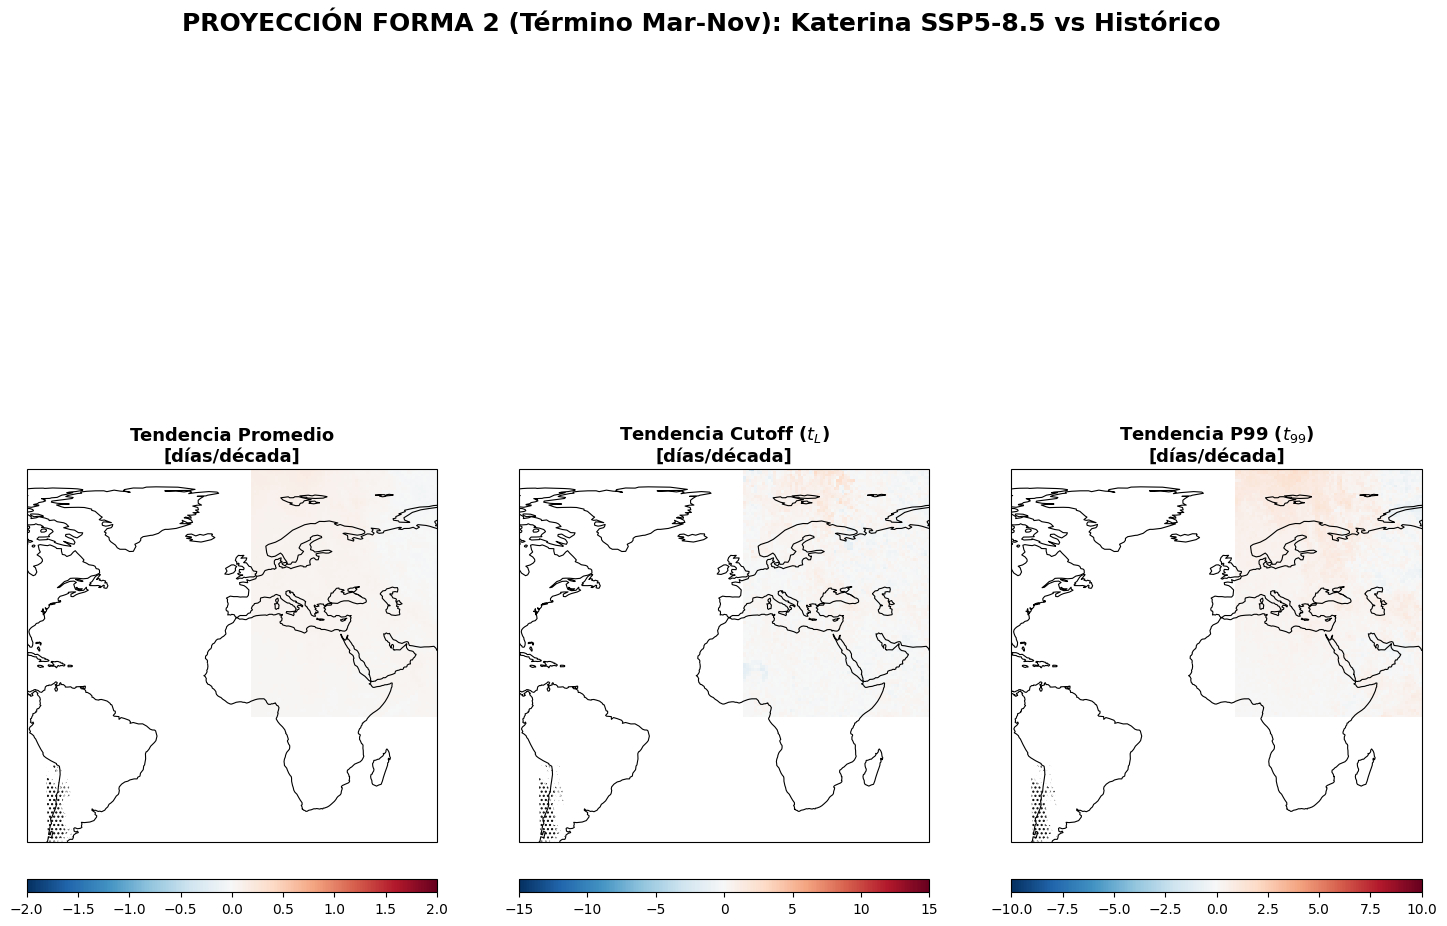

In [10]:
# Wrapper Forma 2
def wrapper_katerina_end(pr1, mo1, pr2, mo2):
    return calc_katerina_trends_and_sig(pr1, mo1, pr2, mo2, filter_type='end')

print("Calculando Proyección FORMA 2 (Katerina SSP5-8.5)...")
res_kat_end = xr.apply_ufunc(
    wrapper_katerina_end, p_hist, m_hist, p_fut_renamed, m_fut,
    input_core_dims=[['time'], ['time'], ['time2'], ['time2']],
    output_core_dims=[['output_var']],
    vectorize=True, dask="forbidden"
).assign_coords(output_var=['trend_mean', 'trend_tL', 'trend_t99', 'pval_mean', 'pval_tL', 'pval_t99'])

# Gráfico Forma 2
fig, axes = plt.subplots(1, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})
for i, ax in enumerate(axes):
    trend_data = res_kat_end.sel(output_var=metrics[i])
    pval_data  = res_kat_end.sel(output_var=pvals[i])
    
    im = trend_data.plot(ax=ax, cmap='RdBu_r', vmin=vmins[i], vmax=vmaxs[i], 
                         add_colorbar=False, transform=ccrs.PlateCarree())
    
    # Puntillado de significancia p < 0.05
    sig_mask = pval_data < 0.05
    if sig_mask.any():
        ax.contourf(trend_data.lon, trend_data.lat, sig_mask, 
                    levels=[0.5, 1.5], colors='none', hatches=['....'], 
                    transform=ccrs.PlateCarree())
    
    ax.coastlines(linewidth=0.8)
    ax.set_title(f"{titles[i]}\n[días/década]", fontweight='bold', fontsize=13)
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, aspect=30)

plt.suptitle("PROYECCIÓN FORMA 2 (Término Mar-Nov): Katerina SSP5-8.5 vs Histórico", fontsize=18, y=0.95, fontweight='bold')
plt.show()

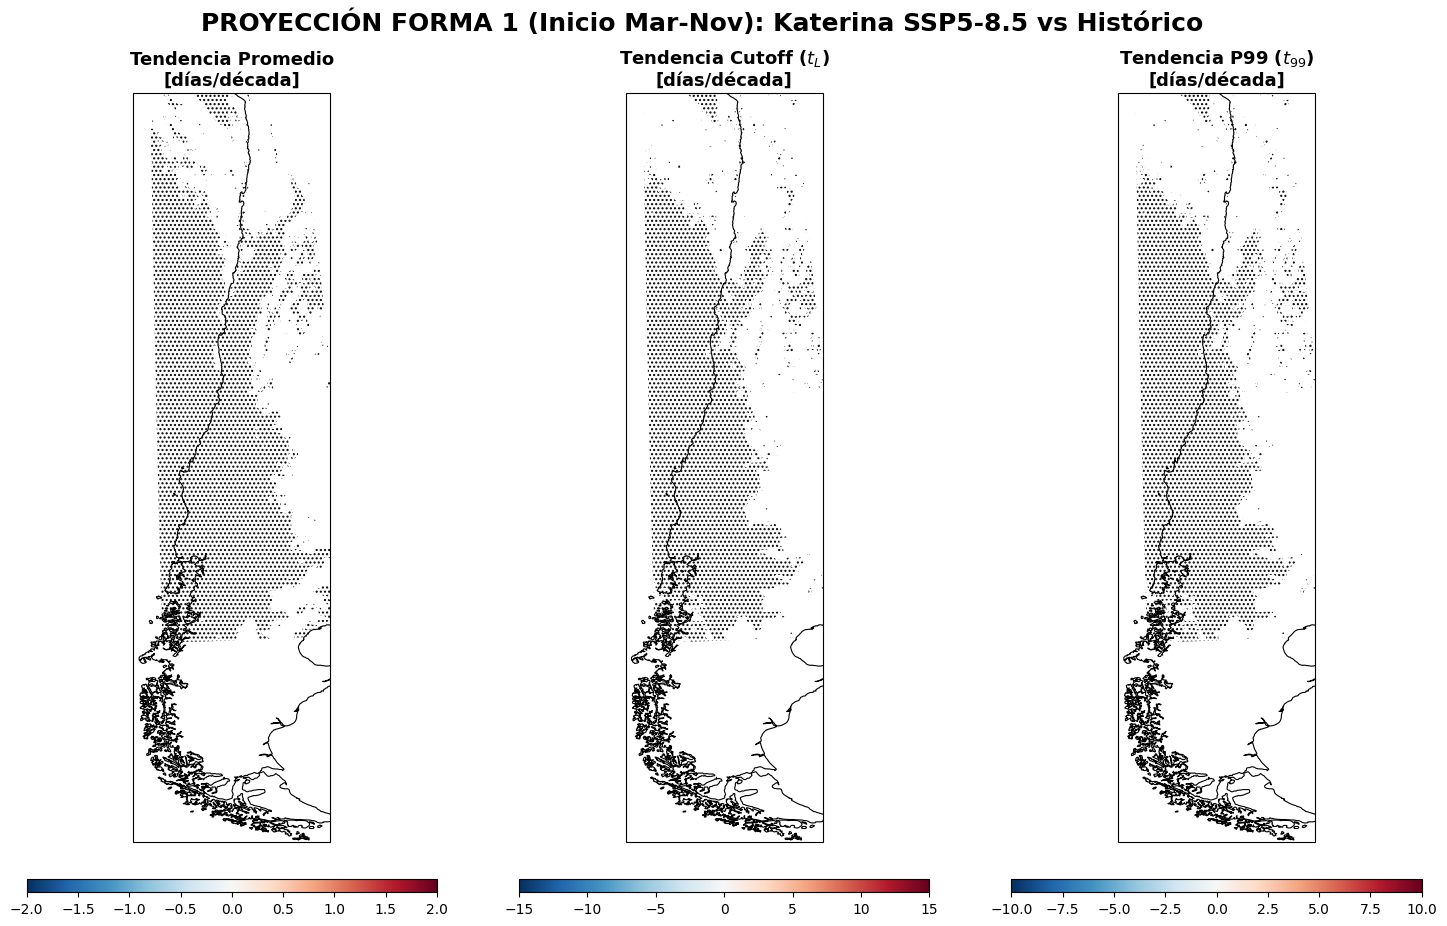

In [13]:
# Gráfico Forma 1 (Corregido con el Encuadre de Chile)
fig, axes = plt.subplots(1, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axes):
    trend_data = res_kat_start.sel(output_var=metrics[i])
    pval_data  = res_kat_start.sel(output_var=pvals[i])
    
    im = trend_data.plot(ax=ax, cmap='RdBu_r', vmin=vmins[i], vmax=vmaxs[i], 
                         add_colorbar=False, transform=ccrs.PlateCarree())
    
    # Puntillado de significancia p < 0.05
    sig_mask = pval_data < 0.05
    if sig_mask.any():
        ax.contourf(trend_data.lon, trend_data.lat, sig_mask, 
                    levels=[0.5, 1.5], colors='none', hatches=['....'], 
                    transform=ccrs.PlateCarree())
    
    ax.coastlines(linewidth=0.8)
    
    # ---> AQUÍ ESTÁ LA LÍNEA CLAVE PARA HACER ZOOM EN CHILE <---
    ax.set_extent([-76, -66, -56, -18], crs=ccrs.PlateCarree())
    
    ax.set_title(f"{titles[i]}\n[días/década]", fontweight='bold', fontsize=13)
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, aspect=30)

plt.suptitle("PROYECCIÓN FORMA 1 (Inicio Mar-Nov): Katerina SSP5-8.5 vs Histórico", fontsize=18, y=0.95, fontweight='bold')
plt.show()

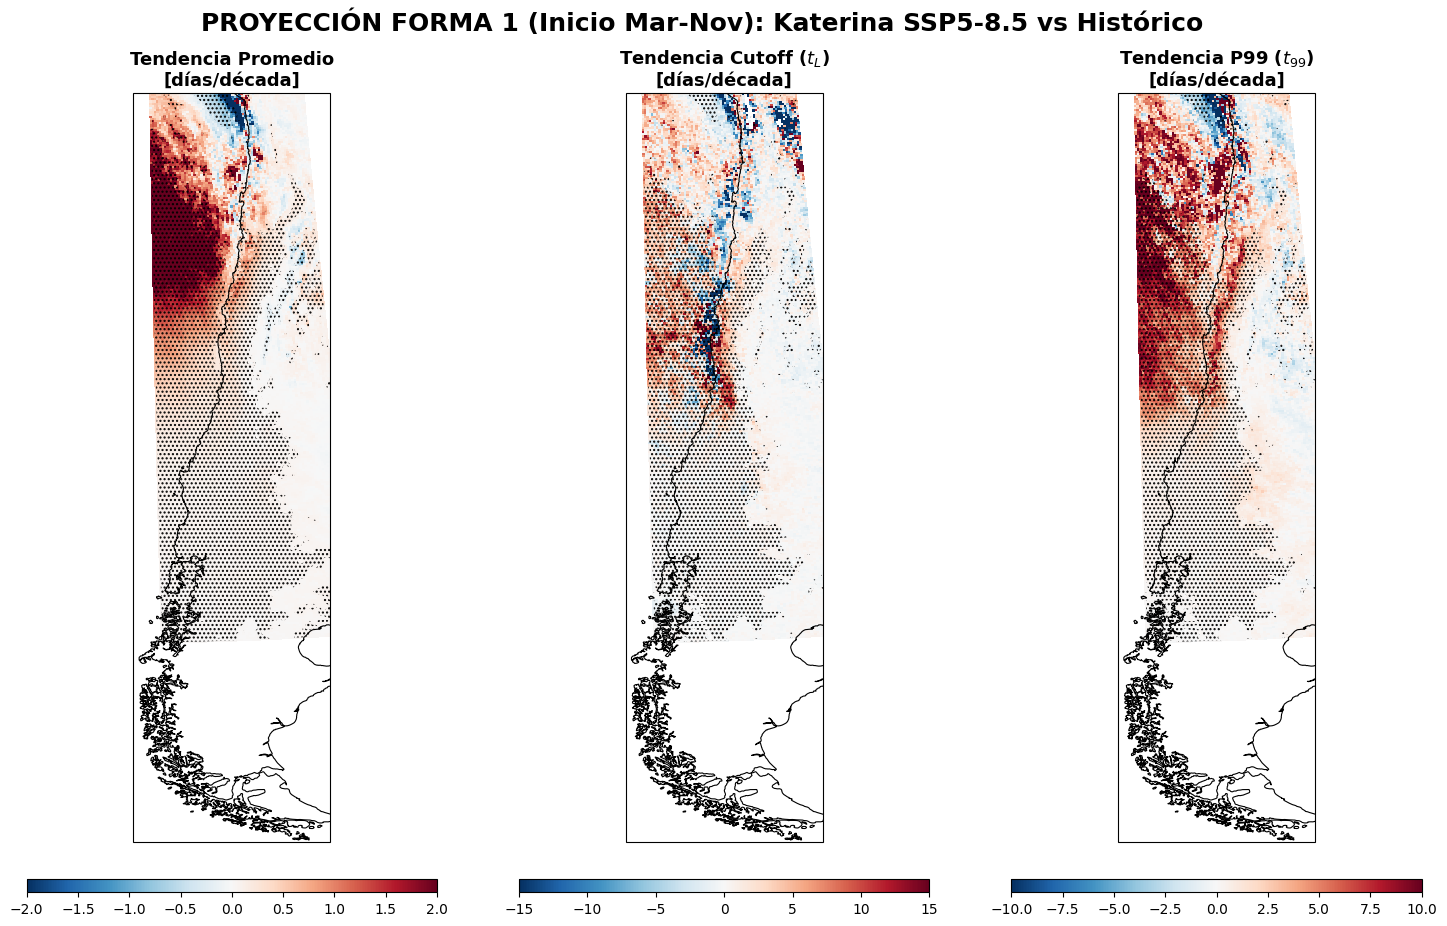

In [14]:
# Gráfico Forma 1
fig, axes = plt.subplots(1, 3, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})

for i, ax in enumerate(axes):
    trend_data = res_kat_start.sel(output_var=metrics[i])
    pval_data  = res_kat_start.sel(output_var=pvals[i])
    
    # LA CORRECCIÓN CLAVE: Usar pcolormesh y decirle x='lon', y='lat'
    im = trend_data.plot.pcolormesh(
        ax=ax, 
        x='lon', y='lat', # <--- Esto obliga a usar las coordenadas geográficas
        cmap='RdBu_r', 
        vmin=vmins[i], vmax=vmaxs[i], 
        add_colorbar=False, 
        transform=ccrs.PlateCarree()
    )
    
    # Puntillado de significancia p < 0.05
    sig_mask = pval_data < 0.05
    if sig_mask.any():
        ax.contourf(trend_data.lon, trend_data.lat, sig_mask, 
                    levels=[0.5, 1.5], colors='none', hatches=['....'], 
                    transform=ccrs.PlateCarree())
    
    # Encuadre de Chile
    ax.coastlines(linewidth=0.8)
    ax.set_extent([-76, -66, -56, -18], crs=ccrs.PlateCarree())
    
    ax.set_title(f"{titles[i]}\n[días/década]", fontweight='bold', fontsize=13)
    cb = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.04, aspect=30)

plt.suptitle("PROYECCIÓN FORMA 1 (Inicio Mar-Nov): Katerina SSP5-8.5 vs Histórico", fontsize=18, y=0.95, fontweight='bold')
plt.show()